<a href="https://colab.research.google.com/github/ramirezuribejesusmiguel-ops/precious-metals-spread-5y/blob/main/precious_metals_spread_5y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the relative growth of gold, silver, palladium, and platinum over the last 5 years, using gold as the baseline. Calculate and visualize the spread between gold and the other metals to identify potential growth opportunities.

## Descargar datos

### Subtask:
Descargar los datos históricos de los precios de cierre del oro, plata, paladio y platino para los últimos 5 años.


**Reasoning**:
The subtask requires downloading historical data for gold, silver, palladium, and platinum using `yfinance`. This involves defining tickers and date ranges, and then using the `yfinance.download()` function to fetch the data. The downloaded data will then be processed to extract 'Close' prices.



In [2]:
import yfinance as yf
from datetime import date, timedelta

# Define the ticker symbols for the metals
tickers = ['GC=F', 'SI=F', 'PA=F', 'PL=F']

# Specify the start and end dates
end_date = date.today()
start_date = end_date - timedelta(days=5*365) # Approximately 5 years

# Download the historical data
data = yf.download(tickers, start=start_date, end=end_date)

# Extract the 'Close' prices for each metal
gold = data['Close']['GC=F'].to_frame()
silver = data['Close']['SI=F'].to_frame()
palladium = data['Close']['PA=F'].to_frame()
platinum = data['Close']['PL=F'].to_frame()

display(gold.head())
display(silver.head())
display(palladium.head())
display(platinum.head())

/tmp/ipython-input-910596989.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed


,GC=F
Date,
2020-09-28,1872.800049
2020-09-29,1894.300049
2020-09-30,1887.500000
2020-10-01,1908.400024
2020-10-02,1900.199951


,SI=F
Date,
2020-09-28,23.528000
2020-09-29,24.379999
2020-09-30,23.433001
2020-10-01,24.193001
2020-10-02,23.971001


,PA=F
Date,
2020-09-28,2258.500000
2020-09-29,2320.100098
2020-09-30,2321.300049
2020-10-01,2319.000000
2020-10-02,2315.800049


,PL=F
Date,
2020-09-28,881.900024
2020-09-29,887.500000
2020-09-30,901.000000
2020-10-01,898.200012
2020-10-02,883.400024


## Combinar y normalizar datos

### Subtask:
Crear un DataFrame con los precios de cierre de los cuatro metales y normalizarlos a 100 tomando como base el precio inicial del oro.


**Reasoning**:
Concatenate the individual metal price DataFrames, calculate the initial gold price, and normalize all prices using this initial gold price as the base.



In [3]:
# Concatenate the 'Close' price DataFrames
combined_prices = pd.concat([gold, silver, palladium, platinum], axis=1)

# Calculate the initial closing price of gold
initial_gold_price = combined_prices['GC=F'].iloc[0]

# Normalize the prices of all four metals
normalized_prices = (combined_prices / initial_gold_price) * 100

# Display the first few rows of the normalized DataFrame
display(normalized_prices.head())

,GC=F,SI=F,PA=F,PL=F
Date,,,,
2020-09-28,100.000000,1.256301,120.594828,47.089919
2020-09-29,101.148014,1.301794,123.884026,47.388935
2020-09-30,100.784918,1.251228,123.948098,48.109781
2020-10-01,101.900896,1.291809,123.825285,47.960273
2020-10-02,101.463045,1.279955,123.654421,47.170013


## Calcular el spread

### Subtask:
Calcular la diferencia en el crecimiento de la plata, paladio y platino con respecto al oro.


**Reasoning**:
Calculate the difference in normalized prices between silver and gold, palladium and gold, and platinum and gold, and store these differences in new columns in the `normalized_prices` DataFrame. Then display the head of the updated DataFrame.



In [4]:
normalized_prices['Spread_SI_GC'] = normalized_prices['SI=F'] - normalized_prices['GC=F']
normalized_prices['Spread_PA_GC'] = normalized_prices['PA=F'] - normalized_prices['GC=F']
normalized_prices['Spread_PL_GC'] = normalized_prices['PL=F'] - normalized_prices['GC=F']

display(normalized_prices.head())

,GC=F,SI=F,PA=F,PL=F,Spread_SI_GC,Spread_PA_GC,Spread_PL_GC
Date,,,,,,,
2020-09-28,100.000000,1.256301,120.594828,47.089919,-98.743699,20.594828,-52.910081
2020-09-29,101.148014,1.301794,123.884026,47.388935,-99.846220,22.736012,-53.759079
2020-09-30,100.784918,1.251228,123.948098,48.109781,-99.533690,23.163180,-52.675137
2020-10-01,101.900896,1.291809,123.825285,47.960273,-100.609087,21.924389,-53.940623
2020-10-02,101.463045,1.279955,123.654421,47.170013,-100.183090,22.191376,-54.293032


## Visualizar los datos

### Subtask:
Graficar el crecimiento relativo de los cuatro metales y el spread de la plata, paladio y platino con respecto al oro.


**Reasoning**:
Plot the normalized prices and the spreads of the precious metals according to the instructions.



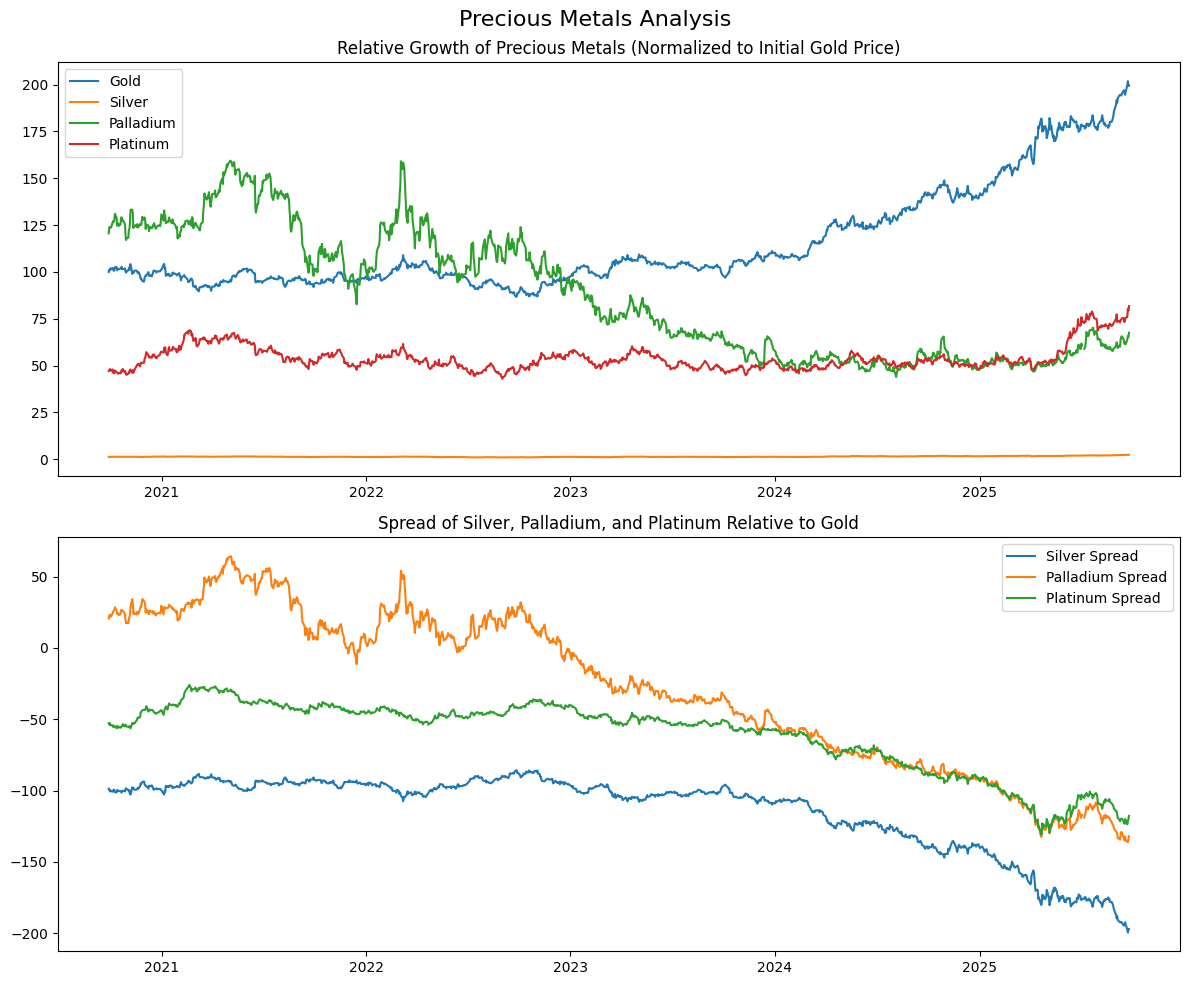

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Plot normalized prices
axes[0].plot(normalized_prices[['GC=F', 'SI=F', 'PA=F', 'PL=F']])
axes[0].set_title("Relative Growth of Precious Metals (Normalized to Initial Gold Price)")
axes[0].legend(['Gold', 'Silver', 'Palladium', 'Platinum'])

# Plot spreads
axes[1].plot(normalized_prices[['Spread_SI_GC', 'Spread_PA_GC', 'Spread_PL_GC']])
axes[1].set_title("Spread of Silver, Palladium, and Platinum Relative to Gold")
axes[1].legend(['Silver Spread', 'Palladium Spread', 'Platinum Spread'])

fig.suptitle("Precious Metals Analysis", fontsize=16)
plt.tight_layout()
plt.show()

## Calcular el crecimiento total

### Subtask:
Calcular el crecimiento total de cada metal en los últimos 5 años y la diferencia de crecimiento de la plata, paladio y platino con respecto al oro.


**Reasoning**:
Calculate the total growth and growth differences and store them in a dictionary.



In [6]:
# Calculate the total growth for each metal
total_growth = {}
for col in ['GC=F', 'SI=F', 'PA=F', 'PL=F']:
  total_growth[col] = normalized_prices[col].iloc[-1] - normalized_prices[col].iloc[0]

# Calculate the growth difference relative to gold
growth_difference = {}
for col in ['SI=F', 'PA=F', 'PL=F']:
  growth_difference[f'Difference_{col}_GC'] = total_growth[col] - total_growth['GC=F']

# Print the results
print("Total Growth:")
for metal, growth in total_growth.items():
  print(f"{metal}: {growth:.2f}")

print("\nGrowth Difference Relative to Gold:")
for diff, value in growth_difference.items():
  print(f"{diff}: {value:.2f}")

Total Growth:
GC=F: 99.54
SI=F: 1.13
PA=F: -53.08
PL=F: 34.64

Growth Difference Relative to Gold:
Difference_SI=F_GC: -98.41
Difference_PA=F_GC: -152.62
Difference_PL=F_GC: -64.89


## Summary:

### Data Analysis Key Findings

*   Over the last 5 years, with gold's initial price normalized to 100, gold's price increased by 99.54 points.
*   In the same period, silver's price increased by 1.13 points, palladium's price decreased by 53.08 points, and platinum's price increased by 34.64 points, based on gold's initial price.
*   The growth of silver was 98.41 points lower than gold's growth.
*   Palladium's growth was 152.62 points lower than gold's growth, indicating a significant underperformance relative to gold.
*   Platinum's growth was 64.89 points lower than gold's growth.
*   The visualizations show that while gold and platinum have generally trended upwards over the last 5 years, silver has shown less consistent growth, and palladium has experienced a significant decline.
*   The spread plots highlight the divergence in performance, particularly the substantial negative spread of palladium and the smaller but still negative spreads of silver and platinum relative to gold.

### Insights or Next Steps

*   The analysis indicates that gold has been the best-performing metal among the four over the last 5 years based on normalized growth. Palladium has performed the worst.
*   Further analysis could investigate the factors driving the significant decline in palladium prices and the reasons for the differing performance among these precious metals, potentially including industrial demand, supply issues, and macroeconomic factors.
